# Level 2 - Task 1: Predicting House Prices with Linear Regression

**Objective:** Build and evaluate a linear regression model that predicts house prices based on features such as area, location, number of rooms, and age. Develop end-to-end skills from data cleaning through to model interpretation.

**Dataset:** Ames Housing Dataset (Kaggle)

**Tools:** Python, pandas, scikit-learn, matplotlib, seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("Dataset/AmesHousing.csv")
print("Shape:", df.shape)
df.head()

Shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


### Load Dataset and Perform EDA: Null Check, Descriptive Statistics, Target Variable Distribution

Shape: (2930, 82)

Null values (top 15 columns with most nulls):
Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Yr Blt      159
Garage Cond        159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
dtype: int64

SalePrice descriptive statistics:
count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64


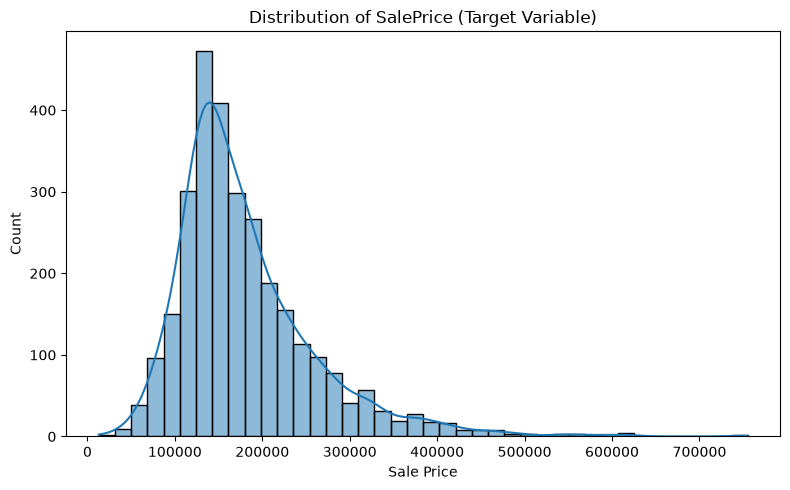

In [2]:
print("Shape:", df.shape)

print("\nNull values (top 15 columns with most nulls):")
print(df.isnull().sum().sort_values(ascending=False).head(15))

print("\nSalePrice descriptive statistics:")
print(df["SalePrice"].describe())

plt.figure(figsize=(8, 5))
sns.histplot(df["SalePrice"], kde=True, bins=40)
plt.title("Distribution of SalePrice (Target Variable)")
plt.xlabel("Sale Price")
plt.tight_layout()
plt.savefig("Images/saleprice_distribution.png", dpi=150)
plt.show()

**Observation:** Several columns have extremely high missing rates — `Pool QC` (~99.6% missing), `Misc Feature` (~96%), `Alley` (~93%), `Fence` (~80%). These are cases where a null actually means "doesn't have this feature" (e.g. no pool) rather than truly missing data. `SalePrice` is right-skewed — the mean ($180,796) is higher than the median ($160,000), and the histogram confirms a long tail toward expensive homes.

### Feature Selection Discussion

Given 82 total columns, we deliberately select a focused, interpretable subset of features likely to predict house price, rather than using everything:

- **Area/size**: `Gr Liv Area`, `Total Bsmt SF`, `Lot Area`
- **Rooms**: `Bedroom AbvGr`, `Full Bath`, `Half Bath`, `TotRms AbvGrd`
- **Age**: `Year Built`, `Year Remod/Add`
- **Location/quality**: `Neighborhood`, `Overall Qual`, `Overall Cond`
- **Garage**: `Garage Cars`, `Garage Area`

These were chosen because they represent fundamental drivers of house value (size, room count, age, location, quality) and have low missing-value rates, unlike columns such as `Pool QC` which are both sparse and less universally predictive.

In [3]:
selected_features = [
    "Gr Liv Area", "Total Bsmt SF", "Lot Area", "Bedroom AbvGr",
    "Full Bath", "Half Bath", "TotRms AbvGrd", "Year Built",
    "Year Remod/Add", "Neighborhood", "Overall Qual", "Overall Cond",
    "Garage Cars", "Garage Area"
]

model_df = df[selected_features + ["SalePrice"]].copy()

print("Shape of selected data:", model_df.shape)
print("\nMissing values in selected features:")
print(model_df.isnull().sum())

Shape of selected data: (2930, 15)

Missing values in selected features:
Gr Liv Area       0
Total Bsmt SF     1
Lot Area          0
Bedroom AbvGr     0
Full Bath         0
Half Bath         0
TotRms AbvGrd     0
Year Built        0
Year Remod/Add    0
Neighborhood      0
Overall Qual      0
Overall Cond      0
Garage Cars       1
Garage Area       1
SalePrice         0
dtype: int64


### Handle Missing Values and Encode Categorical Features

Only 3 missing values remain across our 14 selected features — all in numeric columns, likely representing houses with no basement or no garage (0 makes more sense than an average here). We fill these with 0, then One-Hot Encode `Neighborhood` (our only categorical feature) so the model can use it.

In [4]:
# Fill missing values with 0 (likely means "no basement" / "no garage")
model_df["Total Bsmt SF"] = model_df["Total Bsmt SF"].fillna(0)
model_df["Garage Cars"] = model_df["Garage Cars"].fillna(0)
model_df["Garage Area"] = model_df["Garage Area"].fillna(0)

# One-Hot Encode Neighborhood
model_df = pd.get_dummies(model_df, columns=["Neighborhood"], drop_first=True)

print("Shape after encoding:", model_df.shape)
print("\nRemaining missing values:", model_df.isnull().sum().sum())
model_df.head()

Shape after encoding: (2930, 41)

Remaining missing values: 0


,Gr Liv Area,Total Bsmt SF,Lot Area,Bedroom AbvGr,Full Bath,Half Bath,TotRms AbvGrd,Year Built,Year Remod/Add,Overall Qual,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,1656,1080.0,31770,3,1,0,7,1960,1960,6,...,False,False,False,False,False,False,False,False,False,False
1,896,882.0,11622,2,1,0,5,1961,1961,5,...,False,False,False,False,False,False,False,False,False,False
2,1329,1329.0,14267,3,1,1,6,1958,1958,6,...,False,False,False,False,False,False,False,False,False,False
3,2110,2110.0,11160,3,2,1,8,1968,1968,7,...,False,False,False,False,False,False,False,False,False,False
4,1629,928.0,13830,3,2,1,6,1997,1998,5,...,False,False,False,False,False,False,False,False,False,False


### Correlation Heatmap: Features Most Correlated with House Price

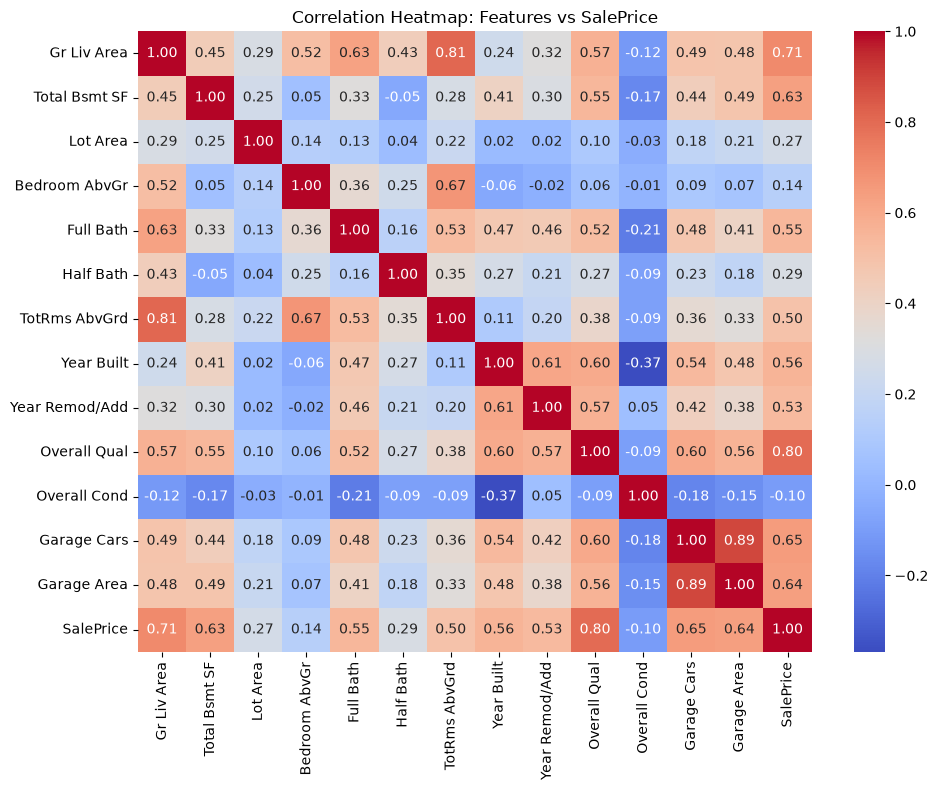

In [5]:
# Correlation of numeric (non-dummy) features with SalePrice
numeric_features = [
    "Gr Liv Area", "Total Bsmt SF", "Lot Area", "Bedroom AbvGr",
    "Full Bath", "Half Bath", "TotRms AbvGrd", "Year Built",
    "Year Remod/Add", "Overall Qual", "Overall Cond",
    "Garage Cars", "Garage Area", "SalePrice"
]

plt.figure(figsize=(10, 8))
corr = model_df[numeric_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap: Features vs SalePrice")
plt.tight_layout()
plt.savefig("Images/correlation_heatmap.png", dpi=150)
plt.show()

**Observation:** `Overall Qual` (0.80) and `Gr Liv Area` (0.71) show the strongest correlation with `SalePrice`, confirming that build/finish quality and living space size are the two biggest price drivers — consistent with real-world intuition. `Garage Cars` and `Garage Area` are almost perfectly correlated with each other (0.89), which is expected since garage capacity and size move together — this is worth watching for multicollinearity. `Overall Cond` shows a weak/slightly negative correlation with price (-0.10), which is counterintuitive but likely reflects that older, lower-condition homes in desirable areas can still be valuable due to location and size.

### Train/Test Split and Train Linear Regression Model

In [6]:
X = model_df.drop(columns=["SalePrice"])
y = model_df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("Model trained successfully.")

Training set size: (2344, 40)
Test set size: (586, 40)
Model trained successfully.


### Model Evaluation: MSE, RMSE, R² Score

In [7]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

Mean Squared Error (MSE): 1,233,612,378.80
Root Mean Squared Error (RMSE): 35,122.82
R² Score: 0.8461


**Observation:** The model achieves an **R² of 0.8461**, meaning it explains about 84.6% of the variance in house prices using only 14 carefully selected features (from 82 available) — a strong result for a simple linear model. The RMSE of ~$35,123 means predictions are typically off by about that amount, which is roughly 19% of the median house price ($160,000) — reasonable for a first-pass model, though there's room for improvement, which we'll explore via the residual plot next.

### Scatter Plot: Actual vs Predicted Prices

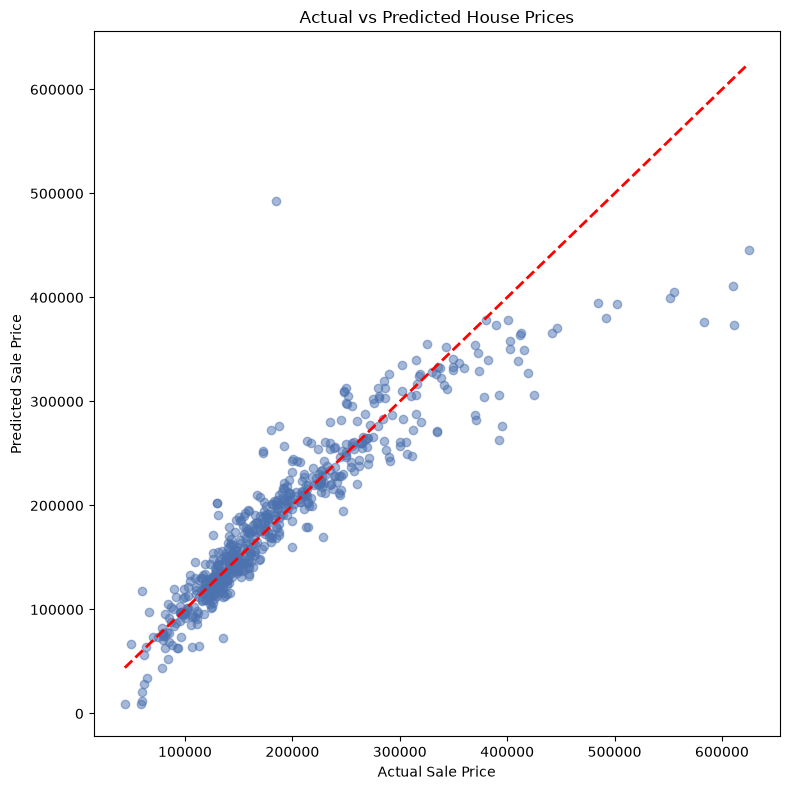

In [8]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color="#4C72B0")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")
plt.tight_layout()
plt.savefig("Images/actual_vs_predicted.png", dpi=150)
plt.show()

**Observation:** The majority of points cluster closely around the diagonal line, confirming the model predicts well for typical-priced homes ($100K-$300K). However, the model consistently **underpredicts expensive homes** — for houses priced above $400K, predicted prices fall noticeably below actual prices (points sit below the diagonal). This suggests luxury homes may have value drivers (e.g. premium finishes, unique architectural features) not fully captured by our 14 selected features, or that the linear model struggles to extrapolate to the upper end of the price range.

### Residual Plot: Checking for Random Distribution

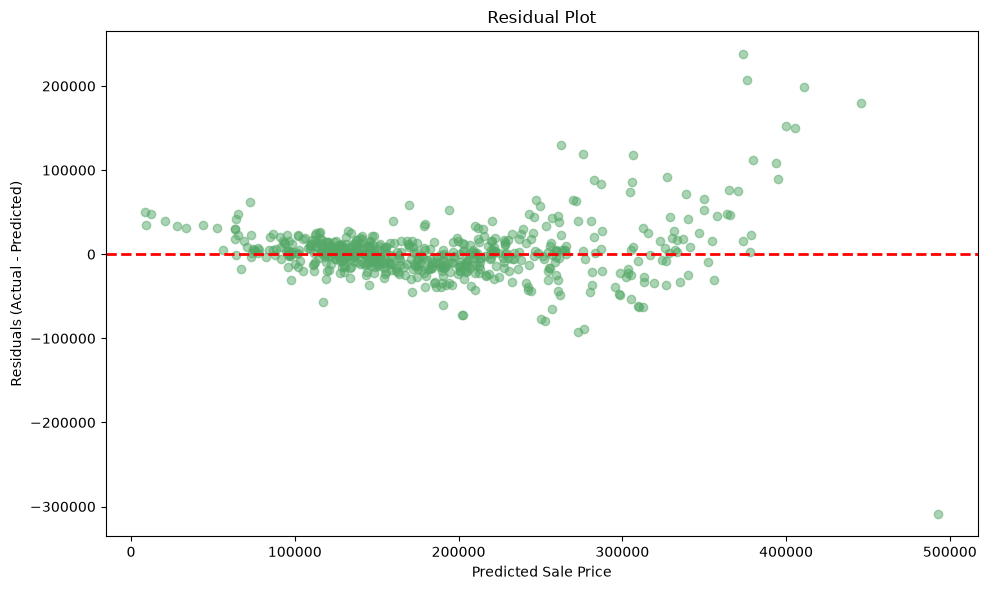

In [9]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5, color="#55A868")
plt.axhline(0, color="red", linestyle="--", lw=2)
plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.tight_layout()
plt.savefig("Images/residual_plot.png", dpi=150)
plt.show()

**Observation:** Residuals cluster tightly and randomly around zero for lower-to-mid predicted prices (up to ~$250K), which is the ideal pattern for a well-fitting model. However, there's a clear **funnel/fan shape** — residual spread widens noticeably as predicted price increases, with several large positive residuals (actual price much higher than predicted) among expensive homes. This is called **heteroscedasticity** and confirms the earlier observation: the model underpredicts luxury homes, and its errors are not uniform across the price range. This is a genuine limitation of this simple linear model, not randomly distributed noise — a more advanced approach (e.g. log-transforming SalePrice, or using a non-linear model) would likely address this in future iterations.

### Coefficient Analysis: Which Features Have the Highest Impact on Price?

In [10]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_model.coef_
}).sort_values("Coefficient", ascending=False)

print("Top 10 positive impact features:")
print(coef_df.head(10))

print("\nTop 10 negative impact features:")
print(coef_df.tail(10))

Top 10 positive impact features:
                 Feature    Coefficient
22  Neighborhood_GrnHill  111456.505914
37  Neighborhood_StoneBr   77410.593884
30  Neighborhood_NoRidge   62718.542114
31  Neighborhood_NridgHt   61621.213509
18  Neighborhood_Crawfor   35140.560895
39  Neighborhood_Veenker   25527.060944
38   Neighborhood_Timber   24929.158955
16  Neighborhood_ClearCr   22986.448894
36  Neighborhood_Somerst   21242.364936
15  Neighborhood_BrkSide   18003.785396

Top 10 negative impact features:
                 Feature   Coefficient
12           Garage Area     13.920776
2               Lot Area      0.691842
5              Half Bath    -57.478798
6          TotRms AbvGrd   -348.760345
4              Full Bath  -2428.646250
28  Neighborhood_NPkVill  -3720.040832
3          Bedroom AbvGr  -5448.557701
24  Neighborhood_Landmrk  -8484.088255
14   Neighborhood_BrDale  -9869.665105
13  Neighborhood_Blueste -16064.387196


**Observation:** Neighborhood dominates the coefficient rankings. Living in **Green Hills (GrnHill)** adds an estimated **$111,457** to a house's price compared to the baseline neighborhood (holding other features constant), followed by **Stone Brook (StoneBr)** at +$77,411 and **Northridge (NoRidge)** at +$62,719 — confirming that location is one of the single strongest price drivers, even more so than size or quality for some premium neighborhoods. On the negative end, **Bluestem (Blueste)** and **Briardale (BrDale)** are associated with the largest price reductions relative to the baseline. Interestingly, `Bedroom AbvGr` (bedroom count) shows a *negative* coefficient (-$5,449) — this is a known effect in regression: once living area is already accounted for, adding more (smaller) bedrooms within the same square footage can actually signal a less desirable layout, rather than adding value.

### Bonus: Comparing Linear Regression Against Ridge Regression

In [11]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=10)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print(f"Linear Regression -> RMSE: {rmse:,.2f}, R²: {r2:.4f}")
print(f"Ridge Regression   -> RMSE: {ridge_rmse:,.2f}, R²: {ridge_r2:.4f}")

Linear Regression -> RMSE: 35,122.82, R²: 0.8461
Ridge Regression   -> RMSE: 35,259.92, R²: 0.8449


**Observation:** Linear Regression (R²=0.8461) performs marginally better than Ridge Regression (R²=0.8449) here. This suggests our 14 hand-picked features aren't suffering from severe overfitting or multicollinearity issues that Ridge's regularization would typically fix — likely because we deliberately selected a small, low-redundancy feature set rather than using all 82 raw columns. Ridge would likely show more benefit on the full, unfiltered dataset where multicollinearity is more severe.

## Conclusion

The Linear Regression model achieved an **R² of 0.8461** and **RMSE of ~$35,123**, explaining about 84.6% of house price variation using just 14 carefully selected, interpretable features out of 82 available.

**Key findings:**
- `Overall Qual` and `Gr Liv Area` are the strongest numeric predictors of price.
- **Neighborhood** has an outsized impact — living in a premium neighborhood like Green Hills can add over $100,000 to a home's value independent of size or quality.
- The model systematically **underpredicts high-value homes** (>$400K), as shown by both the actual-vs-predicted scatter plot and the widening residual spread — indicating luxury homes have value drivers not captured by our current feature set.
- Ridge regularization provided no meaningful improvement, suggesting our feature selection already avoided major multicollinearity issues.

**Future improvements** could include: log-transforming `SalePrice` to address its right-skew and improve high-end predictions, adding more quality-related features (e.g. kitchen/basement quality ratings), or testing non-linear models (Random Forest, Gradient Boosting) to better capture the luxury-home segment.